# Chapter 3: Classification

## MNIST

The MNIST dataset is widely considered the "Hello World" of Machine Learning. It contains 70,000 small images of digits handwritten by high school students and employees of the US Census Bureau. Each image is labeled with the digit it represents.

### Data Fetching and Inspection
We fetch the dataset using `fetch_openml`. A critical engineering point here is that the MNIST dataset returned by this function is already pre-split and strictly sorted into a training set (the first 60,000 images) and a test set (the last 10,000 images). 

Therefore, we do not need to apply a random split function. The training set is also pre-shuffled, ensuring that cross-validation folds will contain a balanced distribution of digits and preventing learning algorithms from being biased by sequences of similar instances.

In [3]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [4]:
X, y = mnist.data, mnist.target

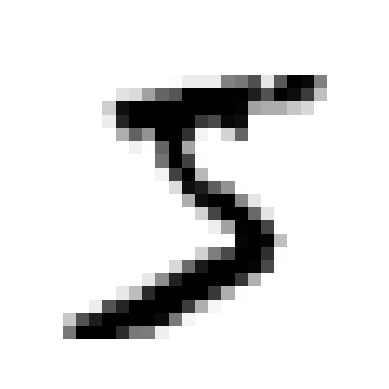

In [5]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [6]:
y[0]

'5'

In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Training a Binary Classifier

Before tackling the full multiclass classification problem, we simplify the task to a binary classifier. We will train a model capable of distinguishing between two classes: "5" and "not-5".

We use a Stochastic Gradient Descent (SGD) classifier. This algorithm is highly efficient for large datasets because it processes training instances independently, making it perfectly suited for online learning systems.

In [9]:
# Target vectors: True for digit 5, False otherwise
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [10]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)
sgd_clf.predict([some_digit])

array([ True])

## Performance Measures
Evaluating a classifier is significantly trickier than evaluating a regressor. If we simply measure accuracy using K-fold cross-validation, the model might score over 90%. However, this is a statistical illusion. Since only about 10% of the images are 5s, a naive model that always guesses "not-5" will automatically be right 90% of the time.

To objectively evaluate the model's true capability, we must abandon simple accuracy and utilize more robust metrics: Confusion Matrix, Precision, Recall, and the F1 Score.

### Measuring Accuracy Using Cross-Validation

In [13]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [14]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
# Returns True if at least one prediction is True
print(any(dummy_clf.predict(X_train)))

False


In [15]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.90965, 0.90965, 0.90965])

### Confusion Matrices

The fundamental concept behind a confusion matrix is to investigate how a classifier is failing, rather than just counting the total errors. To compute this matrix, we need a set of predictions to compare against the actual targets. 

Instead of evaluating on the untouched test set (which must remain strictly locked until the final stage), we use `cross_val_predict` to generate clean out-of-fold predictions.

In [17]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

### Precision and Recall

While the confusion matrix provides complete transparency into the model's errors, it is often more practical in engineering environments to condense this information into concise statistical metrics.

- Precision: The accuracy of the positive predictions. When the model claims an image is a 5, how often is it objectively correct?

- Recall (Sensitivity): The true positive rate. Out of all the actual 5s in the dataset, how many did the model successfully detect?

In [19]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_train_5, y_train_pred)
recall = recall_score(y_train_5, y_train_pred)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')

Precision: 0.8371
Recall: 0.6512


The F1 score is the harmonic mean of precision and recall. Unlike a regular arithmetic mean, the harmonic mean heavily penalizes low values. This ensures that a classifier will only achieve a high F1 score if both recall and precision are high, making it an exceptionally robust and objective metric for evaluating models on highly imbalanced datasets.

In [21]:
from sklearn.metrics import f1_score

f1 = f1_score(y_train_5, y_train_pred)
print(f'F1 Score: {f1:.4f}')

F1 Score: 0.7325


### The Precision/Recall Trade-off

To deeply understand the classifier's performance, we must examine how it makes its decisions. For each instance, the `SGDClassifier` computes a score based on a decision function. If that score is greater than a specified threshold, it assigns the instance to the positive class; otherwise, it assigns it to the negative class.

A critical engineering reality is the Precision/Recall Trade-off: mathematically, increasing the threshold increases precision but reduces recall, and vice versa. 

Scikit-Learn does not let us set the threshold directly, but it does give us access to the underlying decision scores. Let's first look at the score for a single digit and see how changing the threshold affects the prediction.

In [23]:
# Access the raw decision score for a single instance
y_scores = sgd_clf.decision_function([some_digit])
print(f'Decision Score for some_digit: {y_scores:}')

# Test with a threshold of 0 (SGDClassifier's default)
threshold = 0
y_some_digit_pred = (y_scores > threshold)
print(f'Prediction with threshold 0: {y_some_digit_pred}')

Decision Score for some_digit: [2164.22030239]
Prediction with threshold 0: [ True]


In [24]:
# Test with a higher threshold
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
print(f'Prediction with threshold 3000: {y_some_digit_pred}')

Prediction with threshold 3000: [False]


This confirms that raising the threshold decreases recall: the image is actually a 5, but when the threshold is raised to 8000, the classifier misses it.

To decide which threshold to use for the entire project, we need to get the scores of all instances in the training set using `cross_val_predict`, specifying that we want decision scores instead of binary predictions.

In [26]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method='decision_function')

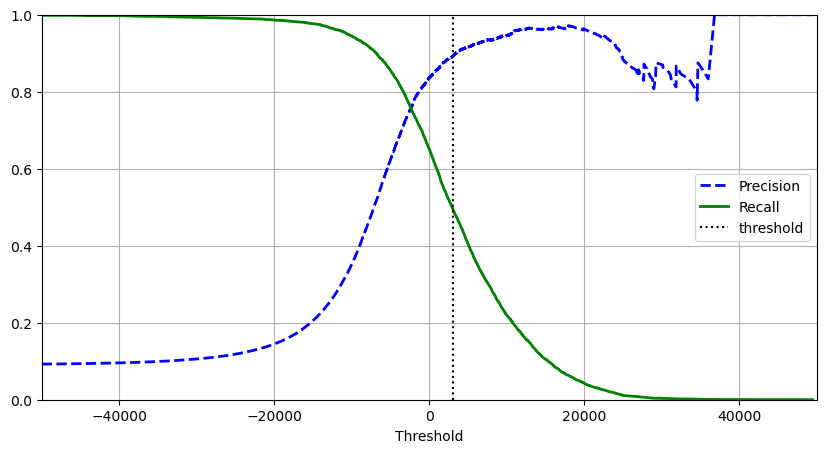

In [27]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', linewidth=2)
plt.vlines(threshold, 0, 1.0, 'k', 'dotted', label='threshold')
plt.xlabel('Threshold')
plt.legend(loc='center right')
plt.grid()
plt.axis([-50000, 50000, 0, 1])
plt.show()

In [28]:
idx = (thresholds >= 3000).argmax()
precision_3000 = precisions[idx]
recall_3000 = recalls[idx]

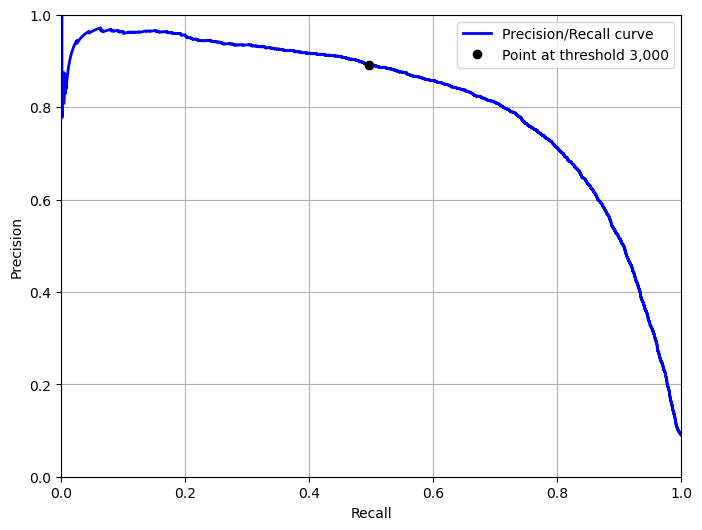

In [29]:
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, 'b-', linewidth=2, label='Precision/Recall curve')
plt.plot([recall_3000], [precision_3000], 'ko', label = 'Point at threshold 3,000')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend()
plt.show()

Suppose the business requires exactly 90% precision. Instead of guessing, we can mathematically search for the lowest threshold that gives us at least 90% precision using `np.argmax`.

In [31]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
print(f'The threshold required to reach 90% precision is {threshold_for_90_precision:.4f}')

The threshold required to reach 90% precision is 3370.0195


In [32]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
precision_at_90 = precision_score(y_train_5, y_train_pred_90)
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)

print(f'Precision at this threshold is {precision_at_90:.4f}')
print(f'Recall at this threshold is {recall_at_90_precision:.4f}')

Precision at this threshold is 0.9000
Recall at this threshold is 0.4800


### The ROC Curve
The Receiver Operating Characteristic (ROC) curve is another critical evaluation tool for binary classifiers. While the Precision/Recall curve plots precision against recall, the ROC curve plots the **True Positive Rate (Recall)** against the **False Positive Rate (FPR)**.

* **FPR:** The ratio of negative instances that are incorrectly classified as positive. It is mathematically equal to 1 minus the True Negative Rate (Specificity).
* Therefore, the ROC curve plots Sensitivity (Recall) versus 1 - Specificity.

To plot the ROC curve, we first need to compute the TPR and FPR for various threshold values using the `roc_curve` function.

In [34]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

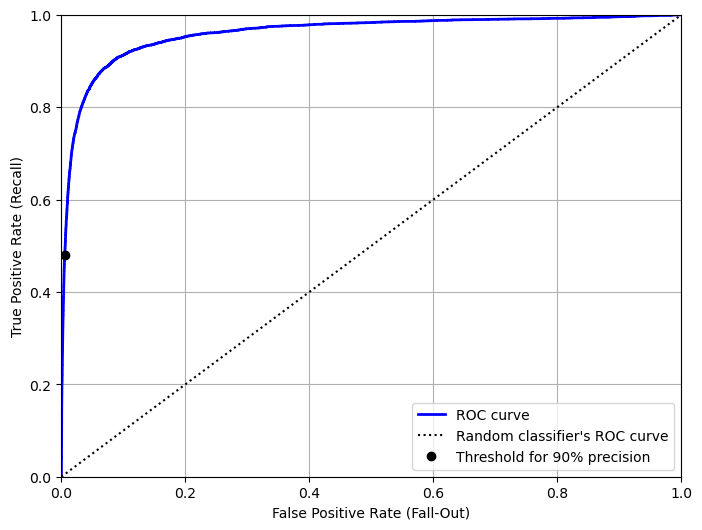

In [35]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], 'ko', label='Threshold for 90% precision')
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend()
plt.show()

Once again, there is a trade-off: the higher the recall (TPR), the more false positives (FPR) the classifier produces. The dotted line represents the ROC curve of a purely random classifier; a good classifier stays as far away from that line as possible (toward the top-left corner).

To objectively compare different classifiers, we can measure the Area Under the Curve (AUC). A perfect classifier will have a ROC AUC equal to 1, whereas a purely random classifier will have a ROC AUC equal to 0.5.

In [37]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_train_5, y_scores)
print(f'ROC AUC score: {roc_auc:.4f}')

ROC AUC score: 0.9605


Since the ROC curve and the Precision/Recall (PR) curve look highly similar, knowing which one to use is a fundamental engineering decision. 

**Rule of Thumb:**
* Use the **PR curve** whenever the positive class is rare, or when you care more about the false positives than the false negatives.
* Use the **ROC curve** otherwise.

In our current model, looking at the ROC curve and the high AUC score, we might mistakenly conclude that the classifier is exceptionally good. However, this is an illusion caused by the fact that there are very few positive instances (5s) compared to the negative instances (non-5s). The PR curve we plotted earlier makes it clear that the classifier still has significant room for improvement (the curve could be closer to the top-right corner).

To objectively evaluate our `SGDClassifier`, we should compare its ROC curve and ROC AUC score to another powerful algorithm, the `RandomForestClassifier`.

A key engineering difference here is how these algorithms compute their predictions. While `SGDClassifier` uses a `decision_function()` to output a continuous confidence score, `RandomForestClassifier` uses a `predict_proba()` method. This method returns an array containing a row per instance and a column per class, representing the probability that the given instance belongs to the given class.

In [39]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method = 'predict_proba')

# Estimated class probabilities for the first two images
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

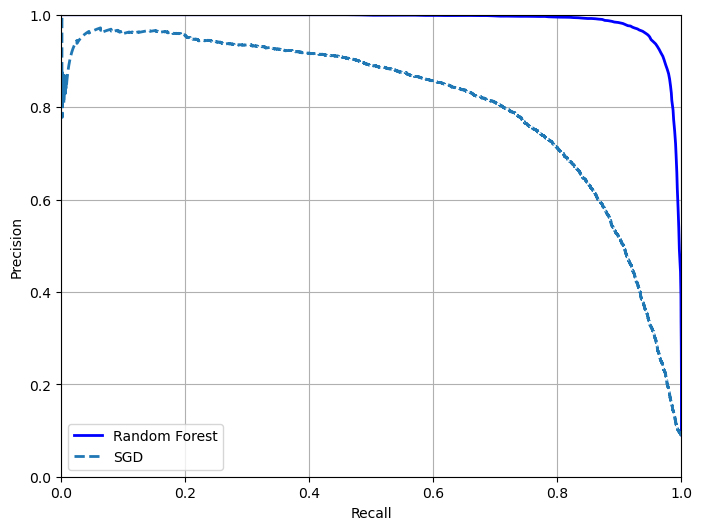

In [40]:
# The second column contains the estimated probabilities for the positive class
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)

plt.figure(figsize=(8, 6))
plt.plot(recalls_forest, precisions_forest, 'b-', linewidth=2,
         label='Random Forest')
plt.plot(recalls, precisions, '--', linewidth=2, label='SGD')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend()
plt.show()

The 'RandomForestClassifier' is superior to the 'SGDClassifier' because its PR curve is much closer to the top-right corner, and it has a greater
AUC

In [42]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5
f1_forest = f1_score(y_train_5, y_train_pred_forest)
roc_auc_forest = roc_auc_score(y_train_5, y_scores_forest)

print(f'Random Forest F1 Score: {f1_forest:.4f}')
print(f'Random Forest ROC AUC Score: {roc_auc_forest:.4f}')

Random Forest F1 Score: 0.9275
Random Forest ROC AUC Score: 0.9983


## Multiclass Classification

Whereas binary classifiers distinguish between two classes, multiclass classifiers can distinguish between more than two. 

Some algorithms such as Random Forest classifiers or naive Bayes classifiers are capable of handling multiple classes natively. Others such as Support Vector Machine classifiers or Linear classifiers are strictly binary classifiers. However, there are engineered strategies to use multiple binary classifiers for a multiclass classification task.

* **OvR (One-versus-the-Rest)** or **OvA (One-versus-All)**: To classify 10 digits, we train 10 separate binary classifiers (one for 0, one for 1, etc.). When predicting, we get the decision score from each classifier and select the class whose classifier outputs the highest score. This is the default strategy for most algorithms.
* **OvO (One-versus-One)**: We train a binary classifier for every possible pair of digits (e.g., 0s vs 1s, 0s vs 2s). For $N$ classes, this requires $N \times (N-1) / 2$ classifiers. For MNIST, this means training 45 classifiers.

Scikit-Learn automatically detects when we try to use a binary classification algorithm for a multiclass task, and it applies OvR or OvO depending on the algorithm. Let's test this using the `SVC` class. A critical engineering step here is to train the model on just the first 2000 images. Support Vector Machines scale very poorly with the size of the training dataset. If we feed the entire 60000 instances to an SVM it will take an excessively long time to compute. For algorithms that scale poorly like SVM it is actually much faster to train 45 classifiers on small datasets (OvO) than to train 10 classifiers on massive datasets (OvR). Therefore Scikit Learn automatically chooses the OvO strategy for SVMs.

In [44]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

svm_prediction = svm_clf.predict([some_digit])
print('SVM Predicted digit:', svm_prediction[0])

SVM Predicted digit: 5


Under the hood Scikit Learn actually trained 45 binary classifiers using the OvO strategy. It evaluated all 45 duels for the given image and selected the class that won the most duels. We can verify this objective fact by calling the `decision_function` method which will return 10 scores (one per class).

In [46]:
some_digit_scores = svm_clf.decision_function([some_digit])
print('SVM Decision Scores:\n', some_digit_scores.round(2))

SVM Decision Scores:
 [[ 3.79  0.73  6.06  8.3  -0.29  9.3   1.75  2.77  7.21  4.82]]


In [47]:
# Verify the highest scores index matches the prediction
class_id = some_digit_scores.argmax()
print('Index of highest score:', class_id)
print('\nList of target classes:', svm_clf.classes_)
print('\nCorresponding Target Class:', svm_clf.classes_[class_id])

Index of highest score: 5

List of target classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']

Corresponding Target Class: 5


### Forcing a Specific Strategy

If you want to force Scikit-Learn to use OvO or OvR, you can use the `OneVsOneClassifier` or `OneVsRestClassifier` classes.

In [49]:
from sklearn.multiclass import OneVsRestClassifier

# Force the OvR strategy on an SVM
ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

ovr_prediction = ovr_clf.predict([some_digit])
print('OvR SVM Predicted digit:', ovr_prediction[0])

# Verify that it trained 10 classifiers instead of 45
print('\nNumber of trained classifiers:', len(ovr_clf.estimators_))

OvR SVM Predicted digit: 5

Number of trained classifiers: 10


### Training and Evaluating the SGD Classifier
Now that we understand the OvO and OvR strategies using SVM, we can train an `SGDClassifier` on the full multiclass dataset.

In [51]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_prediction = sgd_clf.predict([some_digit])

In [52]:
print('SGD Predicted digit:', sgd_prediction[0])
sgd_scores = sgd_clf.decision_function([some_digit])
print('\nSGD Decision Scores:\n', sgd_scores.round())

SGD Predicted digit: 3

SGD Decision Scores:
 [[-31893. -34420.  -9531.   1824. -22320.  -1386. -26189. -16148.  -4604.
  -12051.]]


This time Scikit-Learn used the OvR strategy under the hood: since there are 10 classes, it trained 10 binary classifiers.

The classifier is not very confident in its prediction: most of the scores are highly negative, with class 3 having a score of 1824, while class 5 is relatively close at −1386. It even ended up predicting the wrong class. To make sure the model performs well across the entire dataset, we evaluate it objectively using 3-fold cross-validation.

In [54]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring='accuracy')

array([0.87365, 0.85835, 0.8689 ])

The baseline accuracy is around 87 percent. While this is a solid start, a critical engineering step for linear models is feature scaling. By scaling the input features using `StandardScaler` we reshape the data so that all features share the same scale. This prevents the learning algorithm from struggling with large variable ranges, allowing the gradient descent process to find the optimal solution much faster and with greater stability.

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype('float64'))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring='accuracy')

array([0.8983, 0.891 , 0.9018])

Scaling the inputs successfully pushes our accuracy above 89 percent.

## Error Analysis

In a real world scenario you would typically go through a complete machine learning workflow. This involves exploring data preparation options, trying out multiple models, selecting the best candidates and fine tuning their hyperparameters. However for this section we will assume that you have already found a promising model and want to find ways to improve its performance. One of the most effective ways to do this is to analyze the specific types of errors it makes.

First look at the confusion matrix. Since there are 10 classes, the confusion matrix will contain many values and may be difficult to read, so using `ConfusionMatrixDisplay` helps make it easier to interpret.

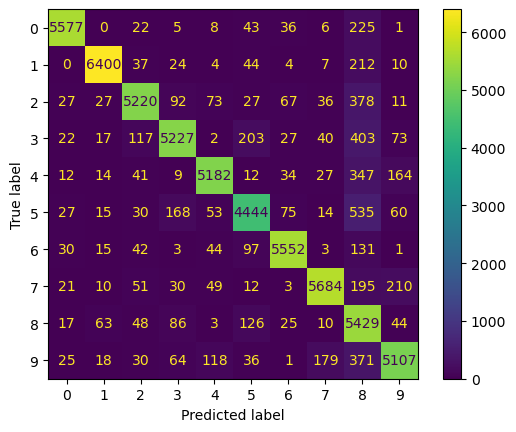

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

This confusion matrix looks pretty good as most images are on the main diagonal. However, the cell on the diagonal in row 5 and column 5 looks slightly darker than the other digits. This could be because the model made more errors on 5s, or because there are fewer 5s in the dataset than the other digits.

To investigate this further, we can normalize the confusion matrix by dividing each value by the total number of images in the corresponding (true) class.

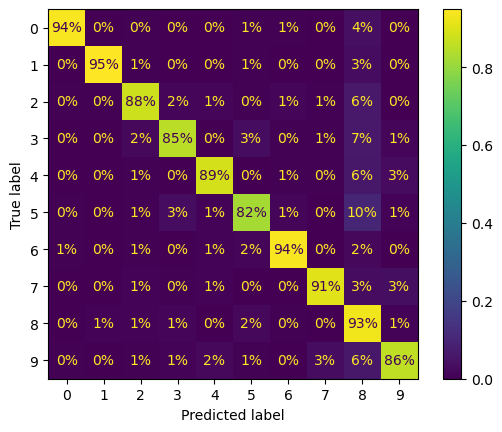

In [61]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize='true', values_format='.0%')
plt.show()

Images of the digit 5 show relatively lower prediction accuracy compared to other classes, with the most common error being misclassification as 8s (10% of all 5s). In fact, it looks like many digits have been misclassified as 8s. To make the errors stand out more, we can try putting zero weight on the correct predictions.

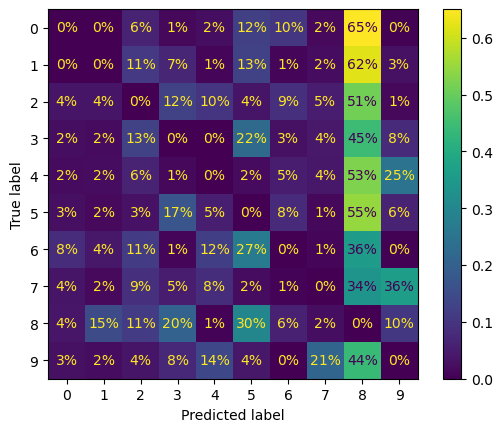

In [107]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize='true', values_format='.0%')
plt.show()

The column for class 8 is very bright, which confirms that many images got misclassified as 8s.

It is also possible to normalize the confusion matrix by column rather than by row.

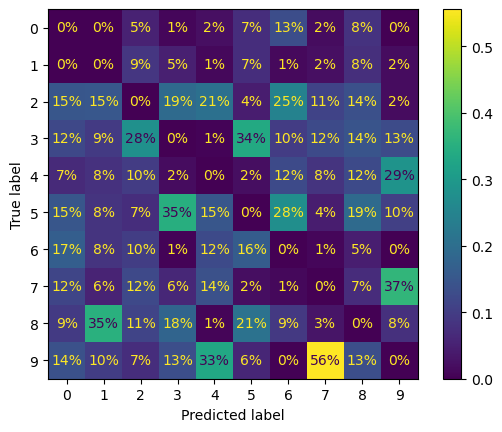

In [111]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize='pred', values_format='.0%')
plt.show()

This time we can see that 56% of misclassified 7s are actually 9s.

Based on these plots, it appears that we should take steps to reduce the number of false 8s.

### Analyzing Individual Errors

Analyzing the confusion matrix gives us macro level insights but investigating individual errors helps us understand exactly why the classifier is failing. For example if we isolate and examine instances where the model specifically confuses 3s and 5s we can uncover the mathematical limitations of our chosen algorithm.

The root cause of these errors lies in the architecture of the `SGDClassifier`. It is a simple linear model. It assigns a weight per class to each pixel and simply sums up the weighted pixel intensities to compute a final score. Since handwritten 3s and 5s differ by only a few pixels in the connecting lines this linear model easily confuses them. It is inherently highly sensitive to image shifting and rotation.

To improve this model we have several engineering options.

* **Data Augmentation:** We can augment the training set by generating slightly shifted and rotated variants of the existing images. This forces the model to learn spatial tolerance and become robust against poorly centered inputs. We will explore this technique in depth in later chapters.
* **Feature Engineering:** We could write an algorithm to count the number of closed loops. For example an 8 has two loops while a 5 has none. We can feed this count as a new custom feature to the model.
* **Image Preprocessing:** We can use libraries like OpenCV or Scikit Image to center the digits perfectly and enhance specific patterns before feeding them to the classifier.

## Multilabel Classification

A multilabel classification system is a classification system that outputs multiple binary tags.

Let's look at a simpler example using our MNIST dataset. We will create a system that outputs two target labels for each digit image. The first indicates whether the digit is large (7, 8, or 9) and the second indicates whether it is odd.

In [137]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

# Make a prediction for the test digit
knn_prediction = knn_clf.predict([some_digit])
print('KNN Multilabel Prediction:', knn_prediction)

KNN Multilabel Prediction: [[False  True]]


There are many ways to evaluate a multilabel classifier and selecting the right metric depends on your specific project. One straightforward approach is to measure the F1 score for each individual label and then compute the average score across all labels.

In [143]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1 = f1_score(y_multilabel, y_train_knn_pred, average='macro')
print('F1 Score:', f1.round(4))

F1 Score: 0.9764


This macro approach assumes that all labels are equally important. If your dataset has a severe imbalance in the number of instances for each label you should set average='weighted' to give each label a weight equal to its support.